# Script for extracting ocean model data and writing field subsets to netCDF

In [2]:
import numpy as np
import xarray as xa
import matplotlib.pyplot as plt
import cmocean
import datetime
import cartopy.crs as ccrs
import pandas as pd
import scipy.ndimage as nd                                                                                                                                                          

In [3]:
# Specify NK800 or Barents2.5, two operational ocean circulation models at the Norwegian Meteorological Institute
model = "NK_new"#"Barents" #"NK" #"NK_old" # "NK_new"

In [4]:
#Read data
if model == "NK_new":
    roms_file = "https://thredds.met.no/thredds/dodsC/fou-hi/norkystv3_800m_m00_be"
elif model == "NK_old":
    roms_file = 'https://thredds.met.no/thredds/dodsC/sea/norkyst800m/1h/aggregate_be'
elif model == "Barents":
    roms_file = 'https://thredds.met.no/thredds/dodsC/barents25km_agg'
    

ocn_m = xa.open_dataset(roms_file)


## File variable naming convention
Here, it important for the user to know the convention of the ocean model. For the two examples provided, the $\mathbf{U} = (U,V)$ components are denoted
- u_eastward, v_northward in NK
- u, v in Barents.

Furthermore, the recall the convention of the depth data, which in the two examples provided use $h$.

## Data subsetting
Data can be subset in terms of 
1. variables (VOI: variables of interest)
2. horizontal extent (AOI: area of interest)
3. temporal extent (TOI: times of interest)

Here we will show an example of such subsetting. First we plot the overview of the data, and an AOI based on the total extent

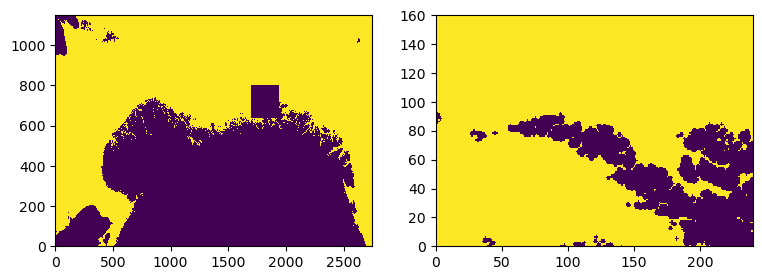

In [10]:
wetmask = ocn_m.h.data > 11.
wetmask = nd.binary_erosion(wetmask)

# Bounding boxes for AOI 
bbox_idx = slice(1700,1940,1) #latitude AOI
bbox_idy = slice(640,800,1) #longitude AOI

fig,ax = plt.subplots(ncols=2,figsize=(9,3))

ax[0].pcolormesh(wetmask)
ax[0].pcolormesh(np.arange(bbox_idx.start,bbox_idx.stop),
                 np.arange(bbox_idy.start,bbox_idy.stop),
                 np.zeros(wetmask[bbox_idy,bbox_idx].shape))
ax[1].pcolormesh(wetmask[bbox_idy,bbox_idx])

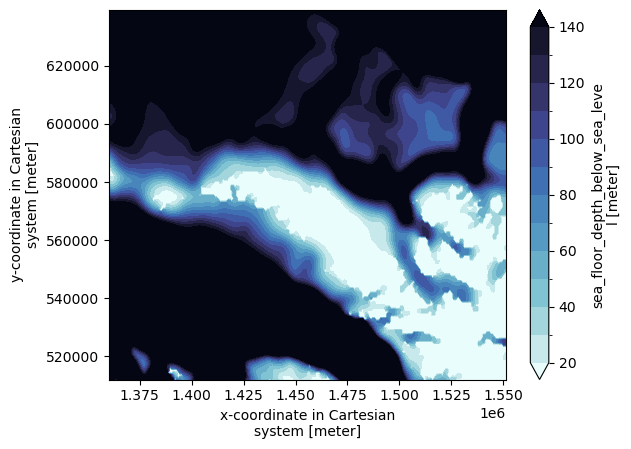

In [11]:
fig,ax=plt.subplots()

ocn_m.h[bbox_idy,bbox_idx].plot.contourf(ax=ax,cmap='cmo.ice_r',levels=np.arange(20,150,10))
#ax.pcolormesh(ocn_m.X[bbox_idx],ocn_m.Y[bbox_idy],wetmask[bbox_idy,bbox_idx],alpha=0.3)


Now, we define the subsets for VOI and TOI

In [18]:
# Variables of interest
VOI = [ 
    'u_eastward',
    'v_northward',
    'h',
    'projection_stere',
    'Uwind_eastward',
    'Vwind_northward',
]

In [19]:
#TOI=pd.date_range("2019-02-19T00",'2019-02-19T07', periods=8)
TOI=pd.date_range("2026-04-02T12",'2026-04-02T23', periods=12)

In [14]:
TOI

DatetimeIndex(['2026-04-02 12:00:00', '2026-04-02 13:00:00',
               '2026-04-02 14:00:00', '2026-04-02 15:00:00',
               '2026-04-02 16:00:00', '2026-04-02 17:00:00',
               '2026-04-02 18:00:00', '2026-04-02 19:00:00',
               '2026-04-02 20:00:00', '2026-04-02 21:00:00',
               '2026-04-02 22:00:00', '2026-04-02 23:00:00'],
              dtype='datetime64[ns]', freq=None)

We then apply the subsets of the ocn_m object utilizing the selection utility of xarray. Note that we only select the surface current layer

In [20]:
ocn_m_subset=ocn_m[VOI].sel(time=TOI,method='nearest').isel(depth=0,X=bbox_idx,Y=bbox_idy)

# Write to NetCDF
Once the subset is created, it can now be written to disk

In [21]:
ocn_m_subset.to_netcdf('nk_subset_nappstraumen.nc')

In [17]:
ocn_m

<xarray.Dataset> Size: 24TB
Dimensions:                  (X: 2747, Y: 1148, depth: 15, time: 20207)
Coordinates:
  * X                        (X) int32 11kB 0 800 1600 ... 2196000 2196800
  * Y                        (Y) int32 5kB 0 800 1600 ... 916000 916800 917600
  * depth                    (depth) float64 120B 0.0 1.0 2.0 ... 200.0 300.0
  * time                     (time) datetime64[ns] 162kB 2024-01-01 ... 2026-...
    lon                      (Y, X) float64 25MB ...
    lat                      (Y, X) float64 25MB ...
Data variables:
    projection_stere         int32 4B ...
    forecast_reference_time  datetime64[ns] 8B ...
    h                        (Y, X) float64 25MB 10.0 10.0 10.0 ... 138.4 136.3
    zeta                     (time, Y, X) float32 255GB ...
    u_eastward               (time, depth, Y, X) float32 4TB ...
    v_northward              (time, depth, Y, X) float32 4TB ...
    w                        (time, depth, Y, X) float32 4TB ...
    temperature              (time, depth, Y, X) float32 4TB ...
    salinity                 (time, depth, Y, X) float32 4TB ...
    AKs                      (time, depth, Y, X) float32 4TB ...
    Uwind_eastward           (time, Y, X) float32 255GB ...
    Vwind_northward          (time, Y, X) float32 255GB ...
Attributes: (12/40)
    id:                         3da8d848-a336-447a-acec-db5623ad388d
    naming_authority:           no.met
    operational_status:         Operational
    iso_topic_category:         oceans
    activity_type:              Numerical Simulation
    keywords_vocabulary:        GCMDSK:GCMD Science Keywords:https://gcmd.ear...
    ...                         ...
    summary:                    Norkyst_v3-800m (Norwegian Coast 800m horizon...
    title_no:                   120 timers prognoser fra havmodellen Norkyst_...
    summary_no:                 NorKyst_v3-800m (Norske kystområder med 800m ...
    contributor_name:           Magne Simonsen, Mateusz Matuszak
    contributor_role:           Technical contact, Metadata author
    contributor_email:          magnes@met.no, mateuszm@met.no